In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    )
from sklearn.model_selection import train_test_split

c:\codetings\433final\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2: Load datasets and define key columns
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

outcome_col = "conversion"
treatment_col = "treatment"

exclude_from_features = {outcome_col, "visit", "exposure"}
feature_cols = [c for c in train_df.columns if c not in exclude_from_features]
X_train = train_df[feature_cols].copy()
y_train = train_df[outcome_col].astype(int)
X_test = test_df[feature_cols].copy()
y_test = test_df[outcome_col].astype(int)

print("Train rows:", len(train_df), "| Test rows:", len(test_df))

Train rows: 582540 | Test rows: 200000


In [3]:
# Cell 3: Train LightGBM S-learner with 50-trial Optuna search (optimize AUPRC)
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# Use pandas categorical dtype so LightGBM can handle categorical features natively.
for col in categorical_cols:
    combined = pd.concat([X_train[col], X_test[col]], axis=0).astype("string")
    categories = pd.Index(combined.dropna().unique())
    X_train[col] = pd.Categorical(X_train[col].astype("string"), categories=categories)
    X_test[col] = pd.Categorical(X_test[col].astype("string"), categories=categories)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
    )

def objective(trial):
    params = {
        "objective": "binary",
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_tr, y_tr, categorical_feature=categorical_cols)
    val_proba = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, val_proba)

study = optuna.create_study(direction="maximize", study_name="s_learner_auprc")
study.optimize(objective, n_trials=50, show_progress_bar=False)

best_params = study.best_params.copy()
best_params.update({"objective": "binary", "random_state": 42, "n_jobs": -1, "verbosity": -1})

s_learner = LGBMClassifier(**best_params)
s_learner.fit(X_train, y_train, categorical_feature=categorical_cols)

print(f"Best validation AUPRC: {study.best_value:.4f}")
print("LightGBM S-learner trained using best Optuna trial on full training data.")

[I 2026-04-08 14:56:00,578] A new study created in memory with name: s_learner_auprc
[I 2026-04-08 14:56:04,872] Trial 0 finished with value: 0.15915910674282324 and parameters: {'n_estimators': 293, 'learning_rate': 0.08576100513442508, 'num_leaves': 121, 'max_depth': 6, 'min_child_samples': 100, 'subsample': 0.8306803328378631, 'colsample_bytree': 0.8891182832220499, 'reg_alpha': 1.0305605813269192, 'reg_lambda': 6.033506912743481e-08}. Best is trial 0 with value: 0.15915910674282324.
[I 2026-04-08 14:56:13,702] Trial 1 finished with value: 0.20946587382579498 and parameters: {'n_estimators': 365, 'learning_rate': 0.021192086886542873, 'num_leaves': 104, 'max_depth': 11, 'min_child_samples': 158, 'subsample': 0.9671501480169153, 'colsample_bytree': 0.7448000669045776, 'reg_alpha': 5.509638209059653e-06, 'reg_lambda': 4.125467032554234e-06}. Best is trial 1 with value: 0.20946587382579498.
[I 2026-04-08 14:56:17,903] Trial 2 finished with value: 0.21420909312074735 and parameters: {'n

Best validation AUPRC: 0.2288
LightGBM S-learner trained using best Optuna trial on full training data.


Test metrics on test.csv
Precision: 0.0000
Recall:    0.0000
Accuracy:  0.9971
AUPRC:     0.2236
Brier:     0.0025


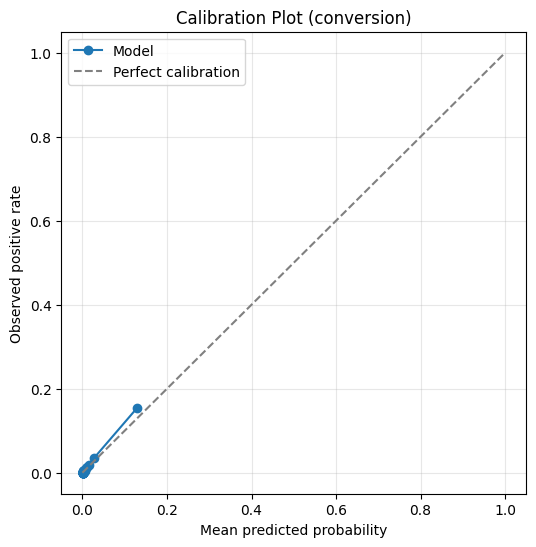

In [9]:
# Cell 4: Evaluate factual performance on test.csv
factual_proba = s_learner.predict_proba(X_test)[:, 1]
factual_pred = (factual_proba >= 0.5).astype(int)

precision = precision_score(y_test, factual_pred, zero_division=0)
recall = recall_score(y_test, factual_pred, zero_division=0)
accuracy = accuracy_score(y_test, factual_pred)
auprc = average_precision_score(y_test, factual_proba)
brier = brier_score_loss(y_test, factual_proba)

print("Test metrics on test.csv")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"AUPRC:     {auprc:.4f}")
print(f"Brier:     {brier:.4f}")

prob_true, prob_pred = calibration_curve(y_test, factual_proba, n_bins=100, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title(f"Calibration Plot ({outcome_col})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [5]:
# Cell 5: Counterfactual conversion predictions with treatment toggled
X_test_treated = X_test.copy()
X_test_control = X_test.copy()
X_test_treated[treatment_col] = 1
X_test_control[treatment_col] = 0

mu1 = s_learner.predict_proba(X_test_treated)[:, 1]  # P(conversion | do(treatment=1), x)
mu0 = s_learner.predict_proba(X_test_control)[:, 1]  # P(conversion | do(treatment=0), x)
uplift = mu1 - mu0

results = test_df.copy()
results["p_conversion_treated"] = mu1
results["p_conversion_control"] = mu0
results["uplift"] = uplift
results

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure,p_conversion_treated,p_conversion_control,uplift
0,23.032518,10.059654,8.214383,4.679882,10.280525,4.115453,-12.422866,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0,0.000779,0.000779,0.000000
1,25.600311,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0,0.000779,0.000779,0.000000
2,19.523195,10.059654,8.639891,3.359763,10.280525,4.115453,-7.301017,4.833815,3.878372,25.240993,5.300375,-0.168679,1,0,0,0,0.001824,0.001714,0.000110
3,12.616365,10.059654,8.422836,4.679882,10.280525,4.115453,0.294443,4.833815,3.835851,18.380112,5.300375,-0.168679,1,0,0,0,0.001723,0.001703,0.000020
4,20.454730,10.059654,8.847605,3.907662,10.280525,4.115453,-10.006574,4.833815,3.899112,13.190056,5.300375,-0.168679,1,0,0,0,0.000861,0.000861,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,12.616365,10.059654,9.040947,4.679882,10.280525,4.115453,0.294443,4.833815,3.943716,13.190056,5.300375,-0.168679,1,0,0,0,0.000781,0.000781,0.000000
199996,24.811454,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0,0.000779,0.000779,0.000000
199997,22.928756,10.059654,8.378748,4.679882,10.280525,3.013064,-15.877431,11.560131,3.771810,46.672202,5.300375,-0.168679,0,0,0,0,0.006350,0.004499,0.001852
199998,12.616365,10.059654,8.841462,4.679882,10.280525,4.115453,0.294443,4.833815,3.943716,13.190056,5.300375,-0.168679,1,0,0,0,0.000781,0.000781,0.000000


In [6]:
# Cell 6: Save best S-learner model to PKL
import pickle

s_learner_bundle = {
    "model": s_learner,
    "feature_cols": feature_cols,
    "categorical_cols": categorical_cols,
    "treatment_col": treatment_col,
    "outcome_col": outcome_col,
    "best_params": best_params,
    "best_validation_auprc": study.best_value,
    "n_optuna_trials": 50,
}

with open("models/s_learner.pkl", "wb") as f:
    pickle.dump(s_learner_bundle, f)

print("Saved best Optuna-tuned model: s_learner.pkl")

Saved best Optuna-tuned model: s_learner.pkl
